# 11 Data Audit

## Purpose
Reproduce the measured facts behind the ISEM 735 design (adaptive measurement scheduling),
and show what lab monitoring looks like in this synthetic data: how often patients are tested,
how far apart the tests are, and whether testing depends on how sick a patient is.

All 100,000 patients are used. The lab table is read with `usecols`, so the full run takes a few seconds.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import brier_score_loss, roc_auc_score

import run_pipeline as rp
from src.evaluation import predict_scores
from src.modeling import load_model

CUTOFF = pd.Timestamp("2021-12-31")  # inputs on or before, targets after
SEED = 42

## Data loading

In [2]:
labs = pd.read_csv(
    DATA_DIR / "lab_results.csv",
    usecols=["patient_id", "test_date", "test_name", "flag"],
    parse_dates=["test_date"],
)
patients = pd.read_csv(DATA_DIR / "patients.csv", usecols=["patient_id", "charlson_index"])
diagnoses = pd.read_csv(DATA_DIR / "diagnoses.csv", usecols=["patient_id", "visit_date", "primary_diagnosis"], parse_dates=["visit_date"])
medications = pd.read_csv(DATA_DIR / "medications.csv", usecols=["patient_id", "start_date", "indication"], parse_dates=["start_date"])
outcomes = pd.read_csv(DATA_DIR / "outcomes.csv", usecols=["patient_id", "admission_date"], parse_dates=["admission_date"])

print(f"lab rows: {len(labs):,} | patients: {len(patients):,}")
print(f"lab dates: {labs.test_date.min().date()} to {labs.test_date.max().date()}")

lab rows: 2,827,722 | patients: 100,000
lab dates: 2018-01-01 to 2024-12-30


## Lab visits

A lab visit is one patient on one date. Each visit is a panel of several tests.

In [3]:
visits = (
    labs.groupby(["patient_id", "test_date"]).size().rename("n_tests").reset_index()
    .sort_values(["patient_id", "test_date"])
)
visits_per_patient = visits.groupby("patient_id").size().reindex(patients.patient_id, fill_value=0)
visits["gap_days"] = visits.groupby("patient_id").test_date.diff().dt.days
gaps = visits.gap_days.dropna()
pre_cutoff = visits[visits.test_date <= CUTOFF].groupby("patient_id").size().reindex(patients.patient_id, fill_value=0)

rho = spearmanr(visits_per_patient.values, patients.set_index("patient_id").charlson_index.loc[visits_per_patient.index].values)
print(f"Spearman rho = {rho.statistic:.4f}, p = {rho.pvalue:.2f}")

Spearman rho = -0.0004, p = 0.89


## Baseline model facts

Recomputed from the saved models on the pipeline's own test split (seed 42, 25% test).
The hospitalization model is XGBoost, the best model for that target.

In [4]:
features = rp.load_feature_table()
model_facts = {}
for target in rp.TARGETS:
    _, X_test, _, y_test = rp.split_for_target(features, target)
    model = load_model(rp.MODELS_DIR / f"{target}_xgboost.joblib")
    score = predict_scores(model, X_test)
    model_facts[target] = {
        "brier": brier_score_loss(y_test, score),
        "roc_auc": roc_auc_score(y_test, score),
        "n_test": len(y_test),
    }
at_risk = len(rp.cohort_for_target(features, "multimorbidity_progression"))
pd.DataFrame(model_facts).T.round(3)

,brier,roc_auc,n_test
future_hospitalization,0.211,0.694,25000.0
multimorbidity_progression,0.145,0.865,10414.0


## Facts table

In [5]:
facts = pd.DataFrame(
    [
        ("Lab visits per patient, mean", visits_per_patient.mean(), 2.58, 0.005),
        ("Lab visits per patient, median", visits_per_patient.median(), 2, 0),
        ("Patients tested only once (share)", (visits_per_patient == 1).mean(), 0.29, 0.005),
        ("Median gap between lab visits (days)", gaps.median(), 431, 0),
        ("Tests per lab visit, mean", visits.n_tests.mean(), 11, 0.5),
        ("Distinct test types", labs.test_name.nunique(), 17, 0),
        ("Lab visits before cutoff per patient, mean", pre_cutoff.mean(), 1.47, 0.005),
        ("Spearman: lab visits vs Charlson index", rho.statistic, 0.00, 0.005),
        ("Hospitalization XGBoost Brier score", model_facts["future_hospitalization"]["brier"], 0.211, 0.0005),
        ("Multimorbidity XGBoost ROC-AUC", model_facts["multimorbidity_progression"]["roc_auc"], 0.865, 0.0005),
        ("At-risk cohort size", at_risk, 41654, 0),
    ],
    columns=["fact", "measured", "handoff", "tolerance"],
)
facts["matches"] = (facts.measured - facts.handoff).abs() <= facts.tolerance
assert facts.matches.all(), facts[~facts.matches]
facts.round(4)

,fact,measured,handoff,tolerance,matches
0,"Lab visits per patient, mean",2.5754,2.580,0.0050,True
1,"Lab visits per patient, median",2.0000,2.000,0.0000,True
2,Patients tested only once (share),0.2894,0.290,0.0050,True
3,Median gap between lab visits (days),431.0000,431.000,0.0000,True
4,"Tests per lab visit, mean",10.9799,11.000,0.5000,True
5,Distinct test types,17.0000,17.000,0.0000,True
6,"Lab visits before cutoff per patient, mean",1.4723,1.470,0.0050,True
7,Spearman: lab visits vs Charlson index,-0.0004,0.000,0.0050,True
8,Hospitalization XGBoost Brier score,0.2114,0.211,0.0005,True
9,Multimorbidity XGBoost ROC-AUC,0.8652,0.865,0.0005,True


## Gaps between lab visits

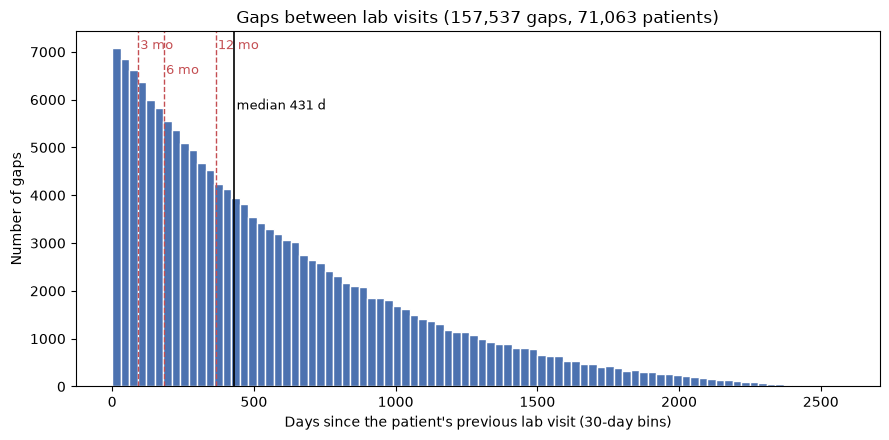

Share of gaps within +/-30 days of a schedule: {'3 mo': '8.2%', '6 mo': '7.3%', '12 mo': '5.6%'}


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(gaps, bins=np.arange(0, gaps.max() + 30, 30), color="#4C72B0", edgecolor="white")
for (days, label), height in zip([(91, "3 mo"), (182, "6 mo"), (365, "12 mo")], [0.95, 0.88, 0.95]):
    ax.axvline(days, color="#C44E52", linestyle="--", linewidth=1)
    ax.text(days + 8, ax.get_ylim()[1] * height, label, color="#C44E52", fontsize=9)
ax.axvline(gaps.median(), color="black", linewidth=1.2)
ax.text(gaps.median() + 8, ax.get_ylim()[1] * 0.78, f"median {gaps.median():.0f} d", fontsize=9)
ax.set_xlabel("Days since the patient's previous lab visit (30-day bins)")
ax.set_ylabel("Number of gaps")
ax.set_title(f"Gaps between lab visits ({len(gaps):,} gaps, {(visits_per_patient > 1).sum():,} patients)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "audit_lab_gap_histogram.png", dpi=150)
plt.show()

share = {m: ((gaps >= lo) & (gaps <= hi)).mean() for m, (lo, hi) in {"3 mo": (61, 120), "6 mo": (152, 212), "12 mo": (335, 395)}.items()}
print("Share of gaps within +/-30 days of a schedule:", {k: f"{v:.1%}" for k, v in share.items()})

## Testing does not follow sickness

Mean lab visits per patient by Charlson index. A flat line means lab timing carries no
information about how sick a patient is.

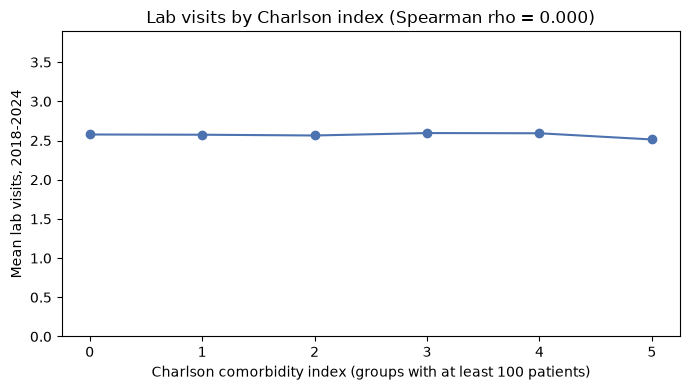

,mean,size
charlson,,
0,2.58,53077
1,2.57,21485
2,2.56,17684
3,2.60,6553
4,2.59,1080
5,2.51,111


In [7]:
by_charlson = (
    pd.DataFrame({"visits": visits_per_patient.values, "charlson": patients.set_index("patient_id").charlson_index.loc[visits_per_patient.index].values})
    .groupby("charlson").visits.agg(["mean", "size"])
)
by_charlson = by_charlson[by_charlson["size"] >= 100]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(by_charlson.index, by_charlson["mean"], marker="o", color="#4C72B0")
ax.set_ylim(0, by_charlson["mean"].max() * 1.5)
ax.set_xlabel("Charlson comorbidity index (groups with at least 100 patients)")
ax.set_ylabel("Mean lab visits, 2018-2024")
ax.set_title(f"Lab visits by Charlson index (Spearman rho = {abs(rho.statistic):.3f})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "audit_visits_by_charlson.png", dpi=150)
plt.show()
by_charlson.round(2)

## Example patient timelines

Three patients picked at random (seed 42) from those with Charlson index 2 or more and at least one
admission: one tested once, one tested twice (the median), and one tested five or more times. Each row is an event type; the dashed line is the input cutoff.

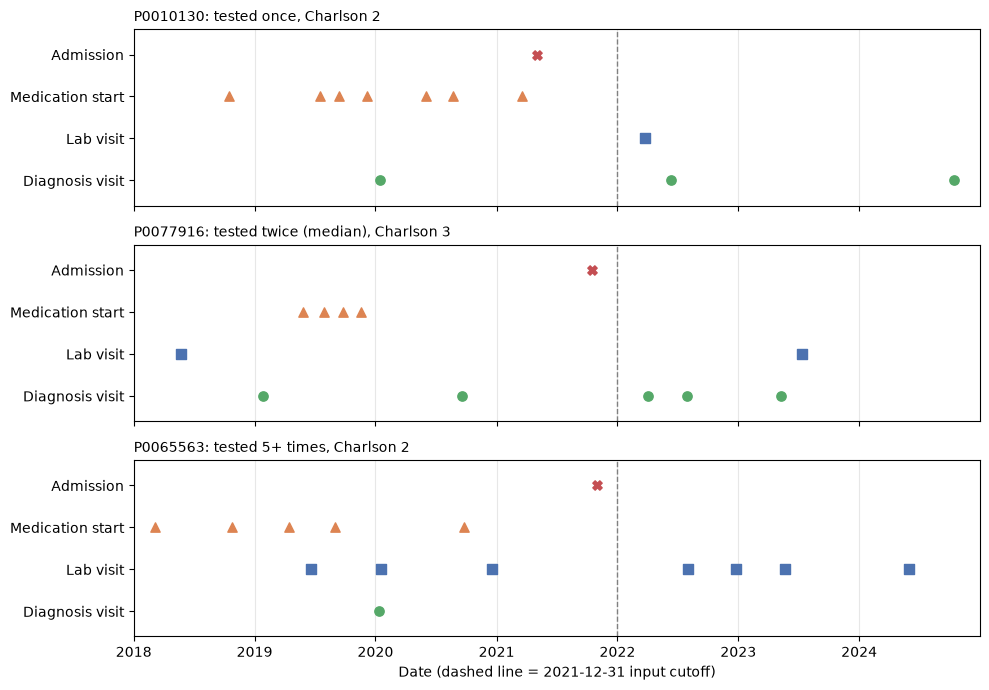

In [8]:
rng = np.random.default_rng(SEED)
sicker = set(patients.loc[patients.charlson_index >= 2, "patient_id"]) & set(outcomes.patient_id)
eligible = visits_per_patient[visits_per_patient.index.isin(sicker)]
groups = {
    "tested once": eligible[eligible == 1].index,
    "tested twice (median)": eligible[eligible == 2].index,
    "tested 5+ times": eligible[eligible >= 5].index,
}
examples = {label: rng.choice(ids) for label, ids in groups.items()}

tracks = [
    ("Diagnosis visit", diagnoses, "visit_date", "#55A868", "o"),
    ("Lab visit", visits, "test_date", "#4C72B0", "s"),
    ("Medication start", medications, "start_date", "#DD8452", "^"),
    ("Admission", outcomes, "admission_date", "#C44E52", "X"),
]
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (label, pid) in zip(axes, examples.items()):
    for row, (name, table, col, color, marker) in enumerate(tracks):
        dates = table.loc[table.patient_id == pid, col]
        ax.scatter(dates, [row] * len(dates), color=color, marker=marker, s=45, zorder=3)
    ax.axvline(CUTOFF, color="grey", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(tracks)), [t[0] for t in tracks])
    ax.set_ylim(-0.6, len(tracks) - 0.4)
    ax.set_title(f"{pid}: {label}, Charlson {patients.set_index('patient_id').charlson_index[pid]}", fontsize=10, loc="left")
    ax.grid(axis="x", alpha=0.3)
axes[-1].set_xlim(pd.Timestamp("2018-01-01"), pd.Timestamp("2024-12-31"))
axes[-1].set_xlabel("Date (dashed line = 2021-12-31 input cutoff)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "audit_patient_timelines.png", dpi=150)
plt.show()

## Key findings

- Every measured fact matches the handoff table within rounding (the assert above enforces it).
- Labs are sparse. The median patient has two lab visits in seven years, and the median gap is over a year.
- Gap lengths fall off smoothly from zero, the shape expected when visit dates are drawn at random.
  About 8% of single gaps land within 30 days of a 3-month interval, but a single gap is not a schedule;
  Task 9 counts patients whose whole history resembles a 3-, 6- or 12-month schedule.
- Lab timing is unrelated to how sick a patient is (Spearman rho is about 0). The synthetic generator
  schedules labs at random, so this data cannot show informative observation.
- The hospitalization model ranks patients reasonably but its probabilities are badly calibrated (Task 6).

## Saved outputs

`outputs/figures/audit_lab_gap_histogram.png`, `audit_visits_by_charlson.png`, `audit_patient_timelines.png`.